# SPRL Proto-Role Classification — Evaluation



## 1. Imports & Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# file paths — adjust if needed
NAIVE_FILE = "proto_role_naive_pred.jsonl"
LR_FILE    = "proto_role_predictions.jsonl"

LABELS = ["proto-agent", "proto-patient"]

COLORS = {
    "Naive Classifier":               "#5B8DB8",
    "Logistic Regression Classifier": "#E07B54",
}

print("Setup complete.")

Setup complete.


## 2. Load Predictions

In [2]:
def load_naive_predictions(filepath):
    """Load naive classifier predictions."""
    predictions = {}
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            predictions[item["spr_id"]] = item["prediction"]
    return predictions


def load_lr_predictions(filepath):
    """Load logistic regression predictions."""
    predictions = {}
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            predictions[item["spr_id"]] = item["predicted_proto_role"]
    return predictions


def load_gold(filepath):
    """Load gold labels from the LR output file."""
    gold = {}
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            gold[item["spr_id"]] = item["gold_proto_role"]
    return gold


def align(gold, predictions):
    """Return aligned y_true / y_pred lists for shared spr_ids."""
    common_ids = sorted(set(gold) & set(predictions))
    y_true = [gold[sid] for sid in common_ids]
    y_pred = [predictions[sid] for sid in common_ids]
    return y_true, y_pred, common_ids


gold        = load_gold(LR_FILE)
naive_preds = load_naive_predictions(NAIVE_FILE)
lr_preds    = load_lr_predictions(LR_FILE)

print(f"Gold labels loaded:         {len(gold)} instances")
print(f"Naive predictions loaded:   {len(naive_preds)} instances")
print(f"LR predictions loaded:      {len(lr_preds)} instances")

Gold labels loaded:         9738 instances
Naive predictions loaded:   9738 instances
LR predictions loaded:      9738 instances


## 3. Evaluation Function

In [3]:
def evaluate(gold, predictions, model_name):
    """Compute metrics and return a results dict."""
    y_true, y_pred, common_ids = align(gold, predictions)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Instances evaluated : {len(common_ids)}")
    print(f"  Accuracy            : {acc:.4f}")
    print(f"  Precision (macro)   : {precision:.4f}")
    print(f"  Recall (macro)      : {recall:.4f}")
    print(f"  F1 (macro)          : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "name":      model_name,
        "accuracy":  acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "y_true":    y_true,
        "y_pred":    y_pred,
    }

## 4. Naive Classifier Results

In [4]:
naive_results = evaluate(gold, naive_preds, "Naive Classifier")


  Naive Classifier
  Instances evaluated : 9738
  Accuracy            : 0.5803
  Precision (macro)   : 0.6702
  Recall (macro)      : 0.7124
  F1 (macro)          : 0.5749

               precision    recall  f1-score   support

  proto-agent       0.36      0.97      0.53      2353
proto-patient       0.98      0.46      0.62      7385

     accuracy                           0.58      9738
    macro avg       0.67      0.71      0.57      9738
 weighted avg       0.83      0.58      0.60      9738



## 5. Logistic Regression Classifier Results

In [5]:
lr_results = evaluate(gold, lr_preds, "Logistic Regression Classifier")


  Logistic Regression Classifier
  Instances evaluated : 9738
  Accuracy            : 0.8547
  Precision (macro)   : 0.8137
  Recall (macro)      : 0.7693
  F1 (macro)          : 0.7873

               precision    recall  f1-score   support

  proto-agent       0.75      0.60      0.67      2353
proto-patient       0.88      0.93      0.91      7385

     accuracy                           0.85      9738
    macro avg       0.81      0.77      0.79      9738
 weighted avg       0.85      0.85      0.85      9738



## 6. Visualisations

### 6.1 Confusion Matrices

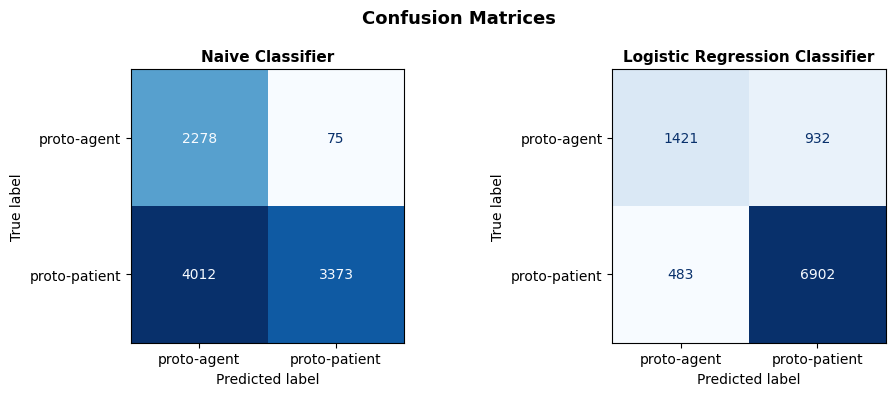

In [6]:
all_results = [naive_results, lr_results]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, res in zip(axes, all_results):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(res["name"], fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Metric Comparison

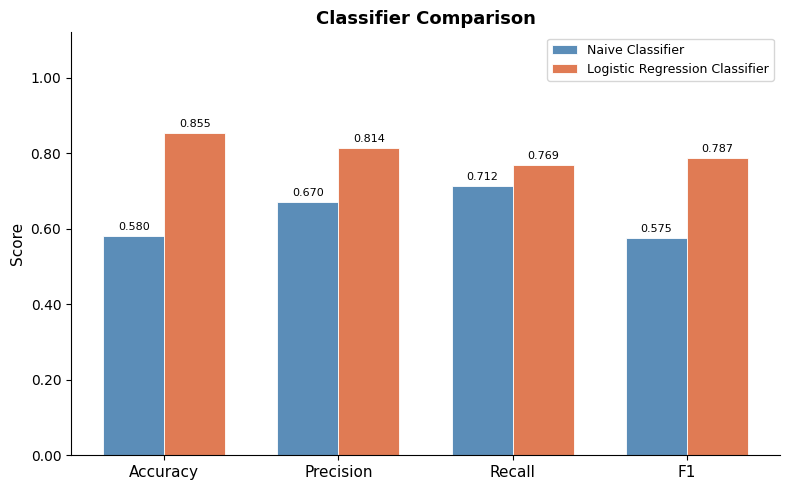

In [7]:
metrics  = ["accuracy", "precision", "recall", "f1"]
x        = np.arange(len(metrics))
width    = 0.35
n        = len(all_results)
offsets  = np.linspace(-(n - 1) * width / 2, (n - 1) * width / 2, n)

fig, ax = plt.subplots(figsize=(8, 5))

for offset, res in zip(offsets, all_results):
    values = [res[m] for m in metrics]
    bars = ax.bar(
        x + offset, values, width,
        label=res["name"],
        color=COLORS.get(res["name"], "#888888"),
        edgecolor="white", linewidth=0.6,
    )
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Classifier Comparison", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()

## 7. Summary

In [9]:
print("=" * 45)
print("  Summary: LR vs Naive")
print("=" * 45)

for metric in ["accuracy", "precision", "recall", "f1"]:
    diff      = lr_results[metric] - naive_results[metric]
    direction = "better" if diff > 0 else "worse" if diff < 0 else "equal"
    print(f"  {metric.capitalize():<12}: LR={lr_results[metric]:.4f}  "
          f"Naive={naive_results[metric]:.4f}  "
          f"Δ={diff:+.4f} ({direction})")

  Summary: LR vs Naive
  Accuracy    : LR=0.8547  Naive=0.5803  Δ=+0.2744 (better)
  Precision   : LR=0.8137  Naive=0.6702  Δ=+0.1435 (better)
  Recall      : LR=0.7693  Naive=0.7124  Δ=+0.0568 (better)
  F1          : LR=0.7873  Naive=0.5749  Δ=+0.2124 (better)
